In [22]:
#importação de bibliotecas e mudança de padrões
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#Por padrão o pandas trunca e mostra só algumas, com ...
#Colocar None remove esse limite e mostra todas as linhas.
pd.set_option('display.max_columns', None)
#muda o padrão de 80 para 200
pd.set_option('display.width', 200)

In [3]:
# importação de dados
df = pd.read_excel(
    '/content/mobile_sales_data_tratado.xlsx',
        parse_dates=['Inward Date', 'Dispatch Date']
)
# descrição geral dos dados
df.describe()

,Price,Inward Date,Dispatch Date,Quantity Sold,RAM_GB,ROM_GB,SSD_GB,Sale_Year,Sale_Month,Dias_Estoque,Revenue
count,50000.000000,50000,50000,50000.00000,50000.000000,50000.000000,25017.000000,50000.00000,50000.000000,50000.00000,5.000000e+04
mean,102641.407080,2024-03-19 17:41:58.272000,2024-04-19 07:54:30.528000,5.51378,13.013760,397.099520,961.731942,2023.80008,6.515400,30.59204,5.655816e+05
min,5008.000000,2023-03-21 00:00:00,2023-03-23 00:00:00,1.00000,4.000000,64.000000,256.000000,2023.00000,1.000000,1.00000,5.046000e+03
25%,53487.000000,2023-09-20 00:00:00,2023-10-20 00:00:00,3.00000,6.000000,128.000000,256.000000,2023.00000,4.000000,16.00000,1.842348e+05
50%,103072.000000,2024-03-19 00:00:00,2024-04-18 00:00:00,6.00000,8.000000,256.000000,1024.000000,2024.00000,7.000000,31.00000,4.393300e+05
75%,151396.250000,2024-09-18 00:00:00,2024-10-19 00:00:00,8.00000,16.000000,512.000000,2048.000000,2024.00000,10.000000,46.00000,8.462238e+05
max,199999.000000,2025-03-20 00:00:00,2025-05-18 00:00:00,10.00000,32.000000,1024.000000,2048.000000,2025.00000,12.000000,60.00000,1.998850e+06
std,56363.550361,NaN,NaN,2.88101,9.388366,348.814327,687.754256,0.67844,3.449638,17.32270,4.578018e+05


Visão Geral


In [4]:
print('Total de registros:', len(df))
print('Receita Total: R$', f'{df['Revenue'].sum():,.2f}')
print('Quantidade total vendida:', df['Quantity Sold'].sum())
print('Ticket médio (Price):', f'{df['Price'].mean():,.2f}')


Total de registros: 50000
Receita Total: R$ 28,279,081,122.00
Quantidade total vendida: 275689
Ticket médio (Price): 102,641.41


aparelhos por região

In [12]:
por_regiao = df.groupby('Region').agg(
    Receita=('Revenue', 'sum'),
    Ticket_Medio=('Price', 'mean')
).sort_values('Receita', ascending=False)
print(por_regiao)

            Receita   Ticket_Medio
Region                            
West     5857063038  103227.389288
South    5617869339  102233.381701
North    5610214922  102257.786116
Central  5601625533  103069.735903
East     5592308290  102404.624708


Gráfico Receita por região

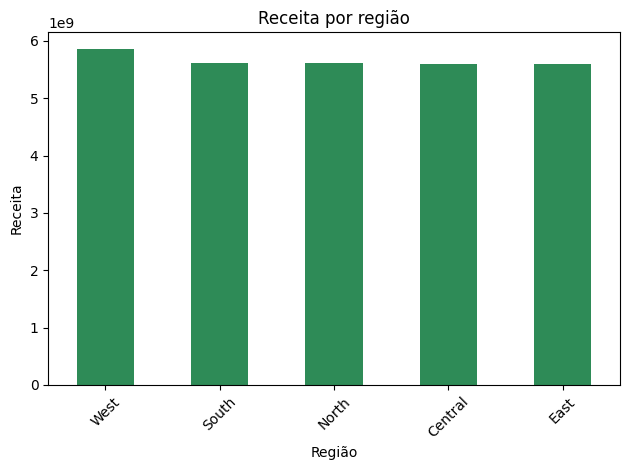

In [13]:
por_regiao['Receita'].plot(kind='bar', color='seagreen')
plt.title('Receita por região')
plt.xlabel('Região')
plt.ylabel('Receita')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Tempo médio de estoque por produto

In [15]:
estoque_produto = df.groupby('Product')['Dias_Estoque'].agg(['mean', 'median', 'std']).round(1)
print(estoque_produto)


              mean  median   std
Product                         
Laptop        30.6    31.0  17.4
Mobile Phone  30.6    31.0  17.3


gráfico tempo médio de estoque

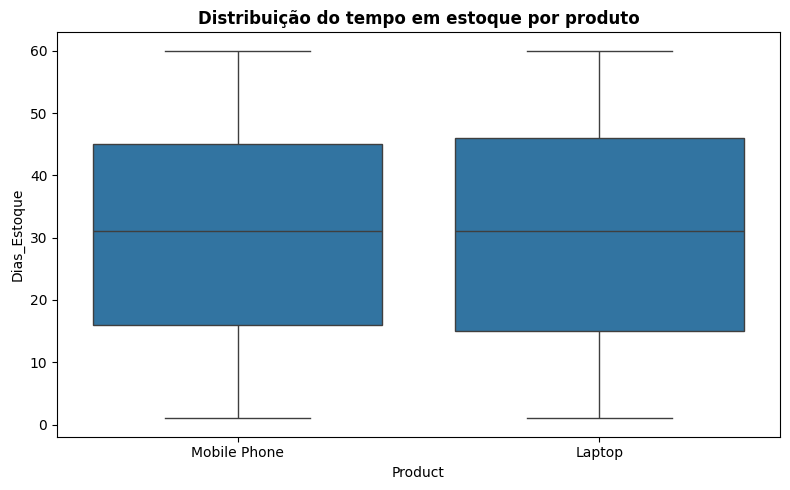

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Product', y='Dias_Estoque', ax=ax)
ax.set_title('Distribuição do tempo em estoque por produto', fontweight='bold')
plt.tight_layout()
plt.show()

Análise temporal

In [28]:
receita_mensal = df.groupby('Sale_YearMonth')['Revenue'].sum()
print(receita_mensal.describe())

count    2.700000e+01
mean     1.047373e+09
std      3.220664e+08
min      4.074200e+07
25%      1.110510e+09
50%      1.161996e+09
75%      1.198265e+09
max      1.273074e+09
Name: Revenue, dtype: float64


Gráfico Análise mensal

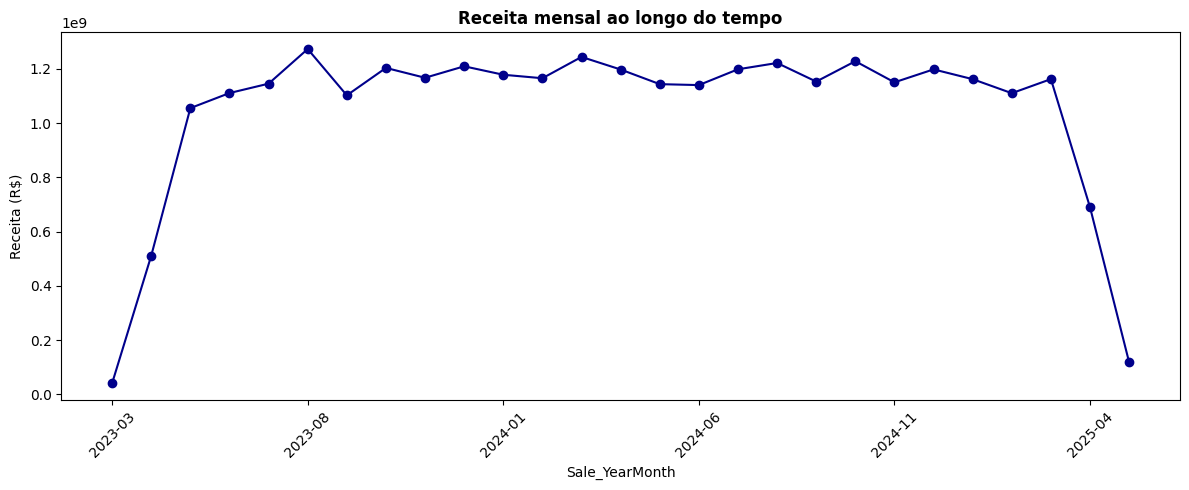

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
receita_mensal.plot(kind='line', marker='o', ax=ax, color='darkblue')
ax.set_title('Receita mensal ao longo do tempo', fontweight='bold')
ax.set_ylabel('Receita (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
variacao = receita_mensal.std() / receita_mensal.mean()
print(f'O coeficiente de variação mensal: {variacao:.2%}')
if variacao >= 0.10:
    print('Há indícios de sazonalidade (variação alta entre os meses).')
else:
    print('Sem indícios de sazonalidade real (variação baixa entre os meses).')


O coeficiente de variação mensal: 30.75%
Há indícios de sazonalidade (variação alta entre os meses).


Por tipo de produto

In [5]:
# uma variavel para agrupar o dataframe pelo produto e, para cada produto, calcular a receita total
# a quantidade total vendida e o preço médio, deixando os números arredondados com duas casas decimais.
por_produto = df.groupby('Product').agg(
    Receita= ('Revenue', 'sum'),
    Qtd=('Quantity Sold', 'sum'),
    Preco_Medio=('Price', 'mean')
).round(2)
print(por_produto)



                  Receita     Qtd  Preco_Medio
Product                                       
Laptop        14187414822  138019    102784.61
Mobile Phone  14091666300  137670    102498.01


Gráfico receita por produto


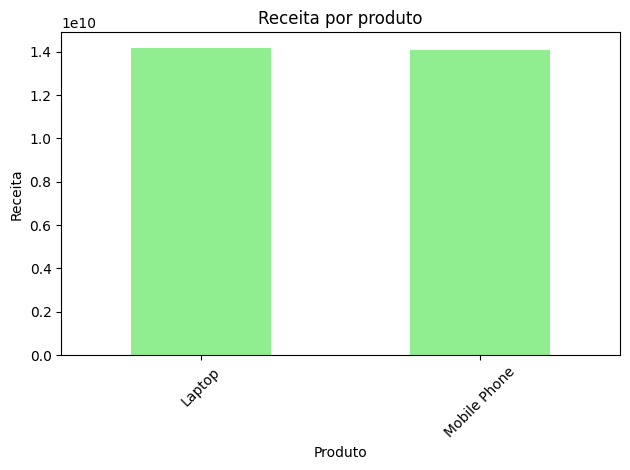

In [6]:
por_produto['Receita'].plot(kind='bar', color='lightgreen')

plt.title('Receita por produto')
plt.xlabel('Produto')
plt.ylabel('Receita')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top marcas por receita

In [7]:
top_brands = df.groupby('Brand')['Revenue'].sum().sort_values(ascending=False)
print(top_brands.head(10))

Brand
Google       1514617084
Nokia        1473167125
Apple        1470242666
Toshiba      1454585835
Sony         1442582351
Samsung      1436721278
Redmi        1432172989
Microsoft    1430065277
Motorola     1420578610
Acer         1419570397
Name: Revenue, dtype: int64


Gráfico top 10 marcas

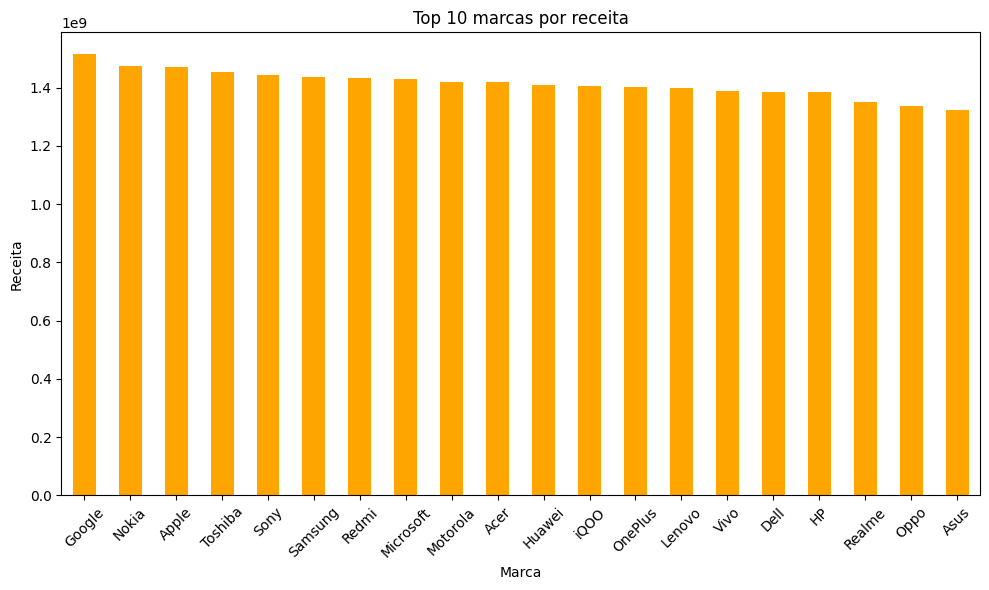

In [8]:
top_brands.plot(kind='bar', figsize=(10, 6), color='orange')

plt.title('Top 10 marcas por receita')
plt.xlabel('Marca')
plt.ylabel('Receita')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()